In [27]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tensorflow.keras.models import load_model
import tensorflow as tf
import random
import os

In [6]:
# ----------------------------------------------------
# 1. 환경 설정 및 경로 정의 (PV 맞춤형)
# ----------------------------------------------------
N_ENSEMBLE = 10
TARGET_NAMES = ["Deflection(mm)", "Weight(kg)"]
MODEL_PATHS = [f'saved_models/pv_ensemble_model_{i+1}.keras' for i in range(N_ENSEMBLE)]
SCALER_DIR = '.' 

# ★ 수정: PSO가 아닌 BO 5% 민감도 결과 사용
BO_RESULT_PATH = 'robustness_analysis_BO_PV/robustness_results_5pct_pv.csv' 
PARETO_OUTPUT_DIR = 'bo_pareto_results_pv'
os.makedirs(PARETO_OUTPUT_DIR, exist_ok=True)

# ----------------------------------------------------
# 2. 모델 및 스케일러 로딩
# ----------------------------------------------------
try:
    ENSEMBLE_MODELS = [load_model(path, compile=False) for path in MODEL_PATHS]
    X_SCALER_LOADED = joblib.load(os.path.join(SCALER_DIR, 'scaler_X_pvmodule.joblib'))
    # PV 모델은 이미 원본 값을 출력하므로 Y 스케일러는 inverse_transform에 사용하지 않음
    print("✅ PV 앙상블 모델 및 X 스케일러 로딩 완료.")
except Exception as e:
    print(f"❌ 로딩 실패: {e}")
    raise

✅ PV 앙상블 모델 및 X 스케일러 로딩 완료.


C:\Users\admin\anaconda3\envs\py31010_auto\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✅ BO 결과 데이터를 불러왔습니다. (Total samples: 50)
파레토 분석을 위한 앙상블 예측 수행 중...


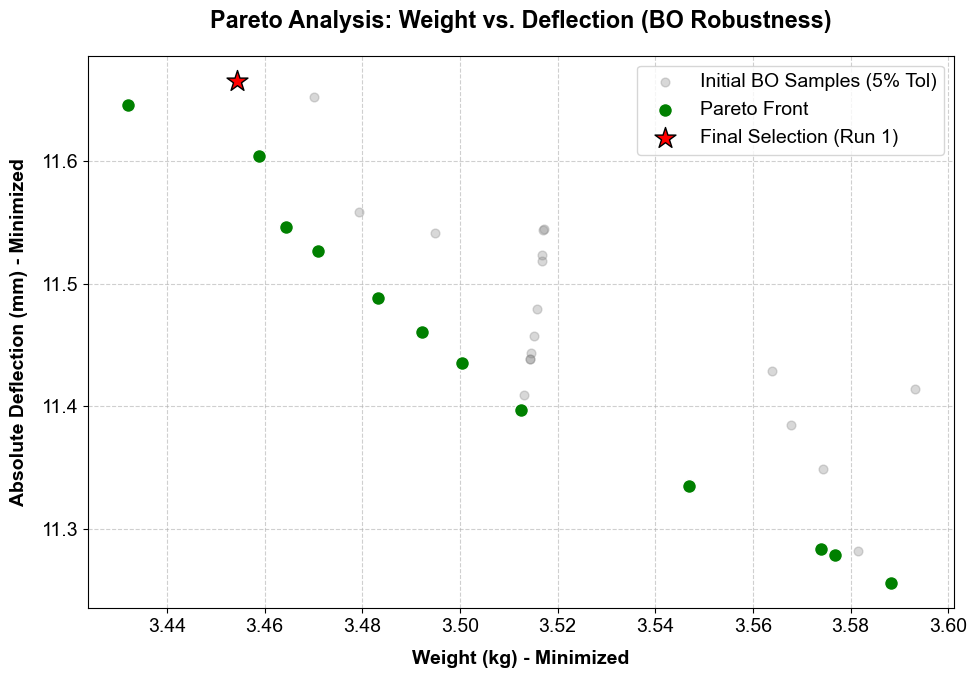

✅ 시각화 완료: 데이터와 이미지가 'bo_pareto_results_pv' 폴더에 저장되었습니다.


In [7]:
# ----------------------------------------------------
# 3. 데이터 로드 및 앙상블 예측 수행
# ----------------------------------------------------
if os.path.exists(BO_RESULT_PATH):
    df_total = pd.read_csv(BO_RESULT_PATH)
    print(f"✅ BO 결과 데이터를 불러왔습니다. (Total samples: {len(df_total)})")
else:
    raise FileNotFoundError(f"❌ 파일을 찾을 수 없습니다: {BO_RESULT_PATH}")

def get_ensemble_predictions(X_array):
    X_scaled = X_SCALER_LOADED.transform(X_array)
    # 딥 앙상블 원본 물리적 값 바로 출력 (inverse_transform 제거)
    preds_raw = np.array([model.predict(X_scaled, verbose=0) for model in ENSEMBLE_MODELS])
    mean_raw = np.mean(preds_raw, axis=0)
    return mean_raw

print("파레토 분석을 위한 앙상블 예측 수행 중...")
# PV는 변수가 5개 (a, b, c, d, e)
y_preds = get_ensemble_predictions(df_total[['a', 'b', 'c', 'd', 'e']].values)
for i, name in enumerate(TARGET_NAMES):
    df_total[name] = y_preds[:, i]

# 파레토 계산을 위해 처짐량을 절댓값으로 변환 (둘 다 '최소화' 문제로 통일)
df_total['Abs_Deflection'] = df_total['Deflection(mm)'].abs()

# ----------------------------------------------------
# 4. 파레토 프론트 계산 함수 (2D 맞춤)
# ----------------------------------------------------
def identify_pareto(df, targets, goals):
    data = df[targets].values.copy()
    for i, goal in enumerate(goals):
        if goal == 'max':
            data[:, i] = -data[:, i]
            
    is_pareto = np.ones(data.shape[0], dtype=bool)
    for i, c in enumerate(data):
        if is_pareto[i]:
            is_pareto[is_pareto] = np.any(data[is_pareto] < c, axis=1)
            is_pareto[i] = True
    return df[is_pareto]

# ----------------------------------------------------
# 5. 2D 파레토 시각화 (Weight vs Deflection)
# ----------------------------------------------------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14

T_COLS = ['Weight(kg)', 'Abs_Deflection']
# 둘 다 낮을수록 좋으므로 min 설정 (무게 가벼울수록 좋음, 처짐량 절댓값 작을수록 튼튼함)
T_GOALS = ['min', 'min'] 

df_pareto_raw = identify_pareto(df_total, T_COLS, T_GOALS)

# [사용자 설정] 강조하고 싶은 Run 번호 (예: F_obj가 가장 높았던 최종 해)
FINAL_SELECTED_RUN = 1  # 확인하신 BO 최적해 Run 번호로 변경하세요!

special_run = df_total[df_total['Run'] == FINAL_SELECTED_RUN]
df_pareto_others = df_pareto_raw[df_pareto_raw['Run'] != FINAL_SELECTED_RUN]

# 시각화 시작 (2D Plot)
fig, ax = plt.subplots(figsize=(10, 7))

# 1. 전체 일반 데이터 (회색)
df_others = df_total[(df_total['Run'] != FINAL_SELECTED_RUN) & (~df_total['Run'].isin(df_pareto_others['Run']))]
ax.scatter(df_others[T_COLS[0]], df_others[T_COLS[1]], 
           color='gray', alpha=0.3, label='Initial BO Samples (5% Tol)', s=40)

# 2. 파레토 프론트 해 (초록색)
ax.scatter(df_pareto_others[T_COLS[0]], df_pareto_others[T_COLS[1]], 
           color='green', label='Pareto Front', s=100, edgecolors='white', zorder=5)

# 3. 최종 선택된 해 단독 강조 (빨간색 별)
if not special_run.empty:
    ax.scatter(special_run[T_COLS[0]], special_run[T_COLS[1]], 
               color='red', label=f'Final Selection (Run {FINAL_SELECTED_RUN})', 
               s=250, marker='*', edgecolors='black', zorder=10)

ax.set_xlabel("Weight (kg) - Minimized", labelpad=10, fontweight='bold')
ax.set_ylabel("Absolute Deflection (mm) - Minimized", labelpad=10, fontweight='bold')
ax.set_title("Pareto Analysis: Weight vs. Deflection (BO Robustness)", pad=20, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()

# 저장 및 출력
img_path = os.path.join(PARETO_OUTPUT_DIR, "PV_Pareto_Weight_vs_Deflection.png")
fig.savefig(img_path, dpi=300)
plt.show()

# 데이터 저장
df_pareto_raw.to_csv(os.path.join(PARETO_OUTPUT_DIR, "BO_Pareto_Solutions_PV.csv"), index=False)
df_total.to_csv(os.path.join(PARETO_OUTPUT_DIR, "BO_Total_Analysis_Data_PV.csv"), index=False)

print(f"✅ 시각화 완료: 데이터와 이미지가 '{PARETO_OUTPUT_DIR}' 폴더에 저장되었습니다.")

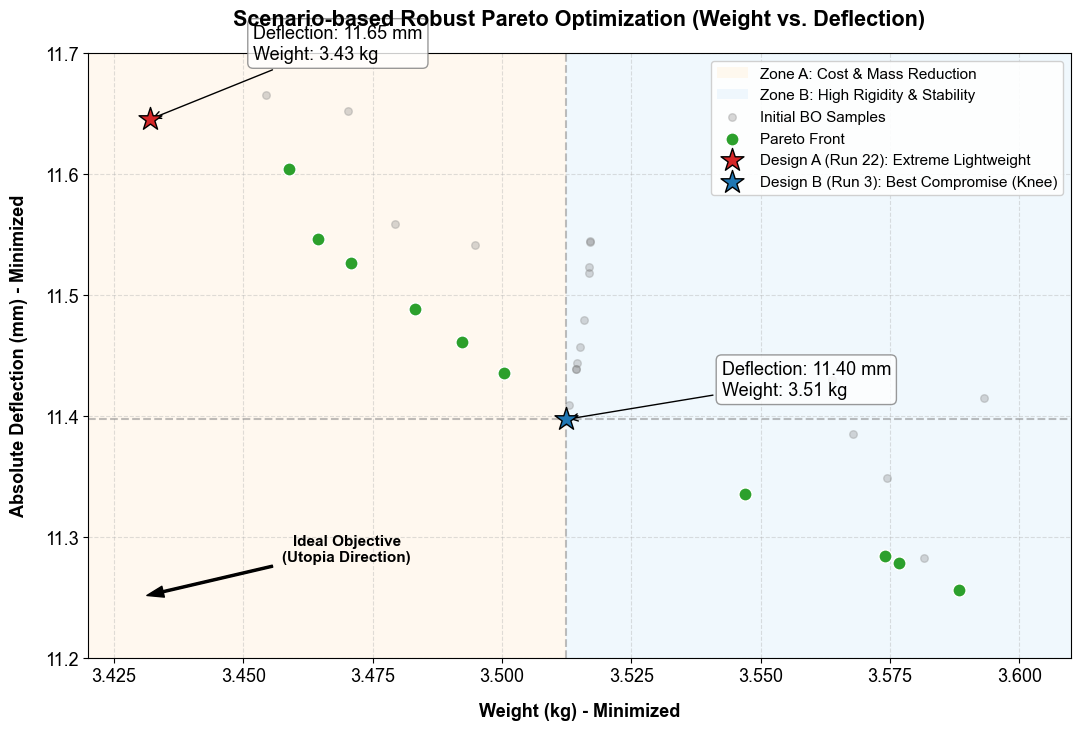

✅ 시각화 완료: 'bo_pareto_results_pv\PV_Pareto_2_Zones.png'


In [9]:
PARETO_OUTPUT_DIR = 'bo_pareto_results_pv'
os.makedirs(PARETO_OUTPUT_DIR, exist_ok=True)

# ----------------------------------------------------
# 2. 하이라이트 할 두 개의 최적해 선정
# ----------------------------------------------------
RUN_LIGHTWEIGHT = 22  # 극한 경량화 (Design A)
RUN_KNEE_POINT = 3    # 최적 밸런스 무릎 지점 (Design B)

run_A = df_total[df_total['Run'] == RUN_LIGHTWEIGHT]
run_B = df_total[df_total['Run'] == RUN_KNEE_POINT]
df_pareto_others = df_pareto_raw[~df_pareto_raw['Run'].isin([RUN_LIGHTWEIGHT, RUN_KNEE_POINT])]

# ----------------------------------------------------
# 3. 고급 논문용 시각화 (2-Zone 분할)
# ----------------------------------------------------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 13

fig, ax = plt.subplots(figsize=(11, 7.5))

# [핵심] 배경 영역(Zone) 색칠
# x축 기준점 (Run 3의 무게를 기준으로 좌우를 나눔, 약 3.51kg)
split_weight = run_B['Weight(kg)'].values[0] 

# Zone 1: 경량화 우선 영역 (옅은 노란색/오렌지)
ax.axvspan(3.42, split_weight, facecolor='#FFF3E0', alpha=0.5, label='Zone A: Cost & Mass Reduction')
# Zone 2: 강성 방어 우선 영역 (옅은 파란색)
ax.axvspan(split_weight, 3.61, facecolor='#E3F2FD', alpha=0.5, label='Zone B: High Rigidity & Stability')

# 점선 기준선 (Knee point 십자선)
ax.axvline(x=split_weight, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=run_B['Abs_Deflection'].values[0], color='gray', linestyle='--', alpha=0.5)

# 1. 초기 탐색 해 (회색)
df_others = df_total[~df_total['Run'].isin(df_pareto_raw['Run'])]
ax.scatter(df_others[T_COLS[0]], df_others[T_COLS[1]], 
           color='gray', alpha=0.3, label='Initial BO Samples', s=30, zorder=3)

# 2. 파레토 프론트 (초록색)
ax.scatter(df_pareto_others[T_COLS[0]], df_pareto_others[T_COLS[1]], 
           color='#2ca02c', label='Pareto Front', s=90, edgecolors='white', zorder=4)

# 3. 최적해 A (경량화 - 빨간 별)
ax.scatter(run_A[T_COLS[0]], run_A[T_COLS[1]], 
           color='#d62728', label='Design A (Run 22): Extreme Lightweight', 
           s=300, marker='*', edgecolors='black', zorder=5)

# 4. 최적해 B (무릎 지점 - 파란 별)
ax.scatter(run_B[T_COLS[0]], run_B[T_COLS[1]], 
           color='#1f77b4', label='Design B (Run 3): Best Compromise (Knee)', 
           s=300, marker='*', edgecolors='black', zorder=5)

# 유토피아 화살표 (왼쪽 아래 방향성 지시)
ax.annotate('Ideal Objective\n(Utopia Direction)', xy=(3.43, 11.25), xytext=(3.47, 11.28),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            fontsize=11, fontweight='bold', ha='center')

# 텍스트 주석 (화살표로 별표 가리키기)
ax.annotate(f'Deflection: {run_A["Abs_Deflection"].values[0]:.2f} mm\nWeight: {run_A["Weight(kg)"].values[0]:.2f} kg',
            xy=(run_A[T_COLS[0]].values[0], run_A[T_COLS[1]].values[0]),
            xytext=(run_A[T_COLS[0]].values[0] + 0.02, run_A[T_COLS[1]].values[0] + 0.05),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3"),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

ax.annotate(f'Deflection: {run_B["Abs_Deflection"].values[0]:.2f} mm\nWeight: {run_B["Weight(kg)"].values[0]:.2f} kg',
            xy=(run_B[T_COLS[0]].values[0], run_B[T_COLS[1]].values[0]),
            xytext=(run_B[T_COLS[0]].values[0] + 0.03, run_B[T_COLS[1]].values[0] + 0.02),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3"),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))


ax.set_xlim([3.42, 3.61])
ax.set_ylim([11.2, 11.7])
ax.set_xlabel("Weight (kg) - Minimized", labelpad=12, fontweight='bold')
ax.set_ylabel("Absolute Deflection (mm) - Minimized", labelpad=12, fontweight='bold')
ax.set_title("Scenario-based Robust Pareto Optimization (Weight vs. Deflection)", pad=20, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)

# 범례를 두 줄로 깔끔하게 정리
ax.legend(loc='upper right', framealpha=0.9, fontsize=11)

plt.tight_layout()
save_path = os.path.join(PARETO_OUTPUT_DIR, "PV_Pareto_2_Zones.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"✅ 시각화 완료: '{save_path}'")

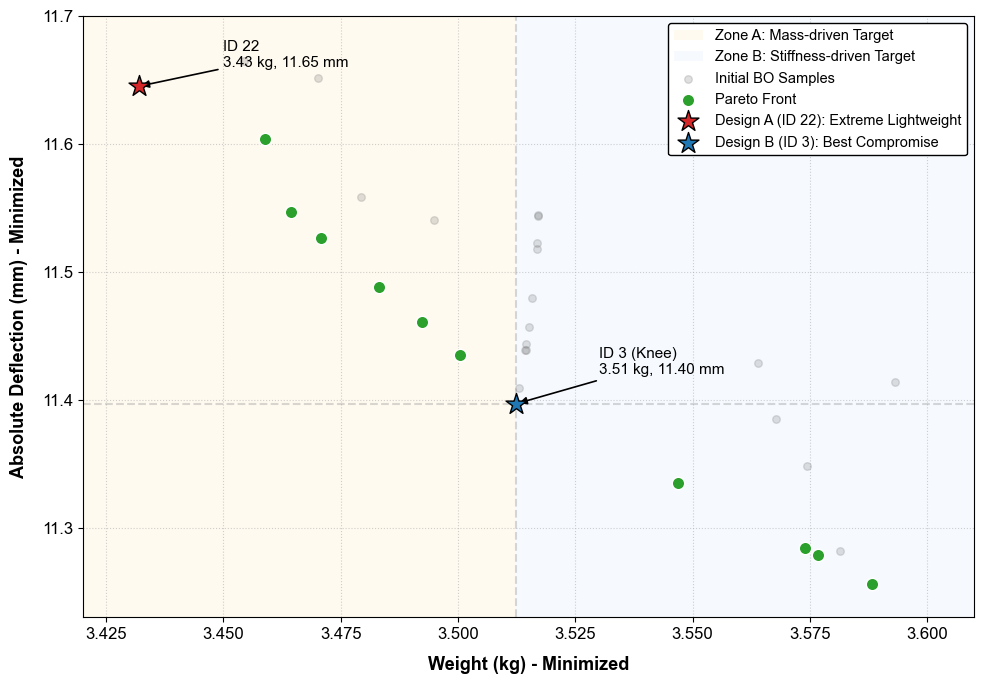

✅ 시각화 완료: 'bo_pareto_results_pv\PV_Pareto_2_Zones_Paper_Ready.png'


In [22]:
# ----------------------------------------------------
# 1. 하이라이트 할 두 개의 최적해 선정 (Run -> ID 명칭 변경)
# ----------------------------------------------------
RUN_LIGHTWEIGHT = 22  
RUN_KNEE_POINT = 3    

run_A = df_total[df_total['Run'] == RUN_LIGHTWEIGHT]
run_B = df_total[df_total['Run'] == RUN_KNEE_POINT]
df_pareto_others = df_pareto_raw[~df_pareto_raw['Run'].isin([RUN_LIGHTWEIGHT, RUN_KNEE_POINT])]

# ----------------------------------------------------
# 2. 미니멀리즘 논문용 시각화 (번잡함 제거, Arial 폰트 세팅)
# ----------------------------------------------------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12 # 전체 기본 글꼴 크기 통일

fig, ax = plt.subplots(figsize=(10, 7)) # 비율을 조금 더 타이트하게 조정

# Zone 분할 (ID 3 기준)
split_weight = run_B['Weight(kg)'].values[0] 

# 색상을 논문에 더 어울리게 한 톤 더 차분하게 조정
ax.axvspan(3.42, split_weight, facecolor='#FFF8E7', alpha=0.6, label='Zone A: Mass-driven Target')
ax.axvspan(split_weight, 3.61, facecolor='#F0F8FF', alpha=0.6, label='Zone B: Stiffness-driven Target')

# 점선 기준선 (투명도를 높여 방해되지 않게)
ax.axvline(x=split_weight, color='gray', linestyle='--', alpha=0.3)
ax.axhline(y=run_B['Abs_Deflection'].values[0], color='gray', linestyle='--', alpha=0.3)

# 산점도 데이터 표시
df_others = df_total[~df_total['Run'].isin(df_pareto_raw['Run'])]
ax.scatter(df_others[T_COLS[0]], df_others[T_COLS[1]], 
           color='gray', alpha=0.25, label='Initial BO Samples', s=30, zorder=3)

ax.scatter(df_pareto_others[T_COLS[0]], df_pareto_others[T_COLS[1]], 
           color='#2ca02c', label='Pareto Front', s=80, edgecolors='white', zorder=4)

# 최적해 하이라이트
ax.scatter(run_A[T_COLS[0]], run_A[T_COLS[1]], 
           color='#d62728', label='Design A (ID 22): Extreme Lightweight', 
           s=250, marker='*', edgecolors='black', zorder=5)

ax.scatter(run_B[T_COLS[0]], run_B[T_COLS[1]], 
           color='#1f77b4', label='Design B (ID 3): Best Compromise', 
           s=250, marker='*', edgecolors='black', zorder=5)

# --- 미니멀한 주석(Annotation) 처리 ---
# 거대한 박스를 없애고 텍스트와 심플한 화살표만 남김
ax.annotate(f'ID 22\n{run_A["Weight(kg)"].values[0]:.2f} kg, {run_A["Abs_Deflection"].values[0]:.2f} mm',
            xy=(run_A[T_COLS[0]].values[0], run_A[T_COLS[1]].values[0]),
            xytext=(3.45, 11.66), # 위치 미세 조정
            arrowprops=dict(arrowstyle="-|>", color='black', lw=1.2),
            fontsize=11, ha='left')

ax.annotate(f'ID 3 (Knee)\n{run_B["Weight(kg)"].values[0]:.2f} kg, {run_B["Abs_Deflection"].values[0]:.2f} mm',
            xy=(run_B[T_COLS[0]].values[0], run_B[T_COLS[1]].values[0]),
            xytext=(3.53, 11.42), # 위치 미세 조정
            arrowprops=dict(arrowstyle="-|>", color='black', lw=1.2),
            fontsize=11, ha='left')

# 축 설정 및 제목(Title) 제거
ax.set_xlim([3.42, 3.61])
ax.set_ylim([11.23, 11.7])
ax.set_xlabel("Weight (kg) - Minimized", labelpad=10, fontweight='bold', fontsize=13)
ax.set_ylabel("Absolute Deflection (mm) - Minimized", labelpad=10, fontweight='bold', fontsize=13)
ax.grid(True, linestyle=':', alpha=0.6)

# 범례 깔끔하게 정리 (그래프 영역을 가리지 않도록 위치 조정)
ax.legend(loc='upper right', framealpha=1.0, edgecolor='black', fontsize=10.5)

plt.tight_layout()
save_path = os.path.join(PARETO_OUTPUT_DIR, "PV_Pareto_2_Zones_Paper_Ready.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ 시각화 완료: '{save_path}'")

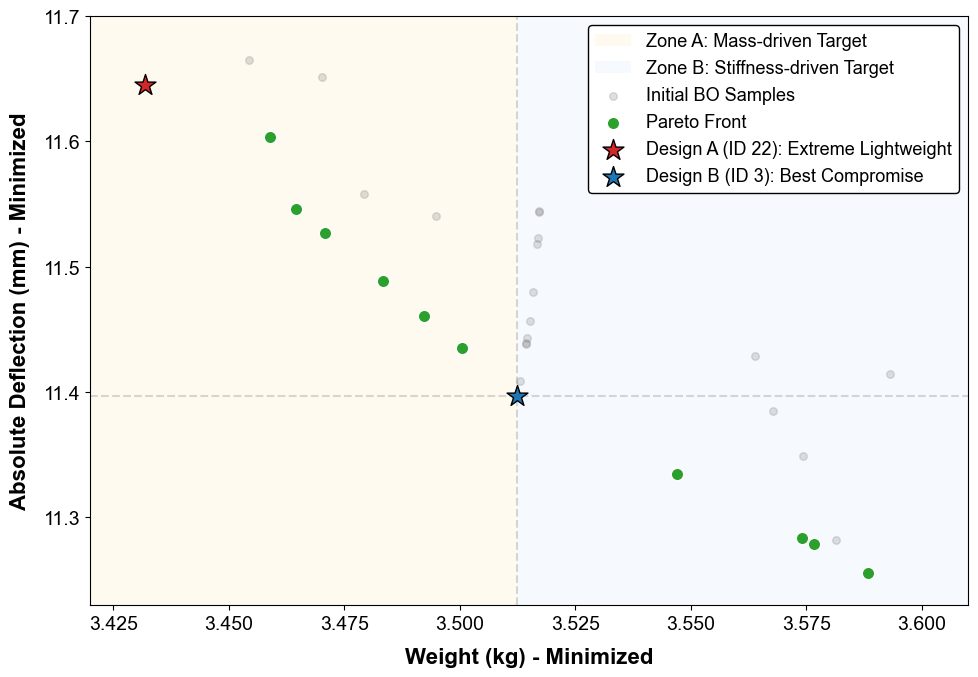

✅ 시각화 완료: 'bo_pareto_results_pv\PV_Pareto_2_Zones_Paper_Ready_f.png'


In [21]:
# ----------------------------------------------------
# 1. 하이라이트 할 두 개의 최적해 선정 (Run -> ID 명칭 변경)
# ----------------------------------------------------
RUN_LIGHTWEIGHT = 22  
RUN_KNEE_POINT = 3    

run_A = df_total[df_total['Run'] == RUN_LIGHTWEIGHT]
run_B = df_total[df_total['Run'] == RUN_KNEE_POINT]
df_pareto_others = df_pareto_raw[~df_pareto_raw['Run'].isin([RUN_LIGHTWEIGHT, RUN_KNEE_POINT])]

# ----------------------------------------------------
# 2. 미니멀리즘 논문용 시각화 (번잡함 제거, Arial 폰트 세팅)
# ----------------------------------------------------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14 # 전체 기본 글꼴 크기 통일

fig, ax = plt.subplots(figsize=(10, 7)) # 비율을 조금 더 타이트하게 조정

# Zone 분할 (ID 3 기준)
split_weight = run_B['Weight(kg)'].values[0] 

# 색상을 논문에 더 어울리게 한 톤 더 차분하게 조정
ax.axvspan(3.42, split_weight, facecolor='#FFF8E7', alpha=0.6, label='Zone A: Mass-driven Target')
ax.axvspan(split_weight, 3.61, facecolor='#F0F8FF', alpha=0.6, label='Zone B: Stiffness-driven Target')

# 점선 기준선 (투명도를 높여 방해되지 않게)
ax.axvline(x=split_weight, color='gray', linestyle='--', alpha=0.3)
ax.axhline(y=run_B['Abs_Deflection'].values[0], color='gray', linestyle='--', alpha=0.3)

# 산점도 데이터 표시
df_others = df_total[~df_total['Run'].isin(df_pareto_raw['Run'])]
ax.scatter(df_others[T_COLS[0]], df_others[T_COLS[1]], 
           color='gray', alpha=0.25, label='Initial BO Samples', s=30, zorder=3)

ax.scatter(df_pareto_others[T_COLS[0]], df_pareto_others[T_COLS[1]], 
           color='#2ca02c', label='Pareto Front', s=80, edgecolors='white', zorder=4)

# 최적해 하이라이트
ax.scatter(run_A[T_COLS[0]], run_A[T_COLS[1]], 
           color='#d62728', label='Design A (ID 22): Extreme Lightweight', 
           s=250, marker='*', edgecolors='black', zorder=5)

ax.scatter(run_B[T_COLS[0]], run_B[T_COLS[1]], 
           color='#1f77b4', label='Design B (ID 3): Best Compromise', 
           s=250, marker='*', edgecolors='black', zorder=5)

# 축 설정 및 제목(Title) 제거
ax.set_xlim([3.42, 3.61])
ax.set_ylim([11.23, 11.7])
ax.set_xlabel("Weight (kg) - Minimized", labelpad=10, fontweight='bold', fontsize=16)
ax.set_ylabel("Absolute Deflection (mm) - Minimized", labelpad=10, fontweight='bold', fontsize=16)
ax.grid(False)

# 범례 깔끔하게 정리 (그래프 영역을 가리지 않도록 위치 조정)
ax.legend(loc='upper right', framealpha=1.0, edgecolor='black', fontsize=13)

plt.tight_layout()
save_path = os.path.join(PARETO_OUTPUT_DIR, "PV_Pareto_2_Zones_Paper_Ready_f.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ 시각화 완료: '{save_path}'")

In [23]:
# ----------------------------------------------------
# 💡 선택된 최적해 (ID 22, ID 3) 상세 수치 확인 코드
# ----------------------------------------------------
TARGET_IDS = [22, 3] # 확인하고 싶은 Run ID (22번: 경량화, 3번: 밸런스)

print("\n" + "="*65)
print(" 🏆 시나리오별 최종 선택 최적해 상세 데이터 (논문 Table 작성용)")
print("="*65)

for run_id in TARGET_IDS:
    # 해당 ID의 행(row) 데이터 추출
    target_data = df_total[df_total['Run'] == run_id].iloc[0]
    
    print(f"\n▶ [ Design ID: {run_id} ]")
    if run_id == 22:
        print("  - 설계 시나리오: Zone A (극한의 경량화 및 재료비 절감 최우선)")
    elif run_id == 3:
        print("  - 설계 시나리오: Zone B (Knee Point, 강성과 경량화의 최적 타협해)")
        
    print("  [ 최적 단면 설계 변수 (Design Factors) ]")
    print(f"    a = {target_data['a']:.4f}")
    print(f"    b = {target_data['b']:.4f}")
    print(f"    c = {target_data['c']:.4f}")
    print(f"    d = {target_data['d']:.4f}")
    print(f"    e = {target_data['e']:.4f}")
    
    print("  [ 딥 앙상블 예측 성능 (Predicted Targets) ]")
    print(f"    처짐량 (Deflection) : {target_data['Abs_Deflection']:.4f} mm (안전 한계선: 12.3 mm)")
    print(f"    단면 무게 (Weight)  : {target_data['Weight(kg)']:.4f} kg (안전 한계선: 3.6 kg)")
    print("-" * 65)


 🏆 시나리오별 최종 선택 최적해 상세 데이터 (논문 Table 작성용)

▶ [ Design ID: 22 ]
  - 설계 시나리오: Zone A (극한의 경량화 및 재료비 절감 최우선)
  [ 최적 단면 설계 변수 (Design Factors) ]
    a = 1.5000
    b = 14.0000
    c = 1.5000
    d = 2.4204
    e = 2.5000
  [ 딥 앙상블 예측 성능 (Predicted Targets) ]
    처짐량 (Deflection) : 11.6451 mm (안전 한계선: 12.3 mm)
    단면 무게 (Weight)  : 3.4319 kg (안전 한계선: 3.6 kg)
-----------------------------------------------------------------

▶ [ Design ID: 3 ]
  - 설계 시나리오: Zone B (Knee Point, 강성과 경량화의 최적 타협해)
  [ 최적 단면 설계 변수 (Design Factors) ]
    a = 1.5000
    b = 14.0000
    c = 1.5000
    d = 3.0000
    e = 2.5000
  [ 딥 앙상블 예측 성능 (Predicted Targets) ]
    처짐량 (Deflection) : 11.3970 mm (안전 한계선: 12.3 mm)
    단면 무게 (Weight)  : 3.5125 kg (안전 한계선: 3.6 kg)
-----------------------------------------------------------------


In [28]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 분석할 두 최적해의 입력 변수 (a, b, c, d, e)
# 주의: ID 22의 d는 FEA 검증과 동일하게 2.4로 맞춤
TARGET_DESIGNS = {
    "Design A (ID 22)": [1.5000, 14.0000, 1.5000, 2.4000, 2.5000],
    "Design B (ID 3)":  [1.5000, 14.0000, 1.5000, 3.0000, 2.5000]
}
TARGET_NAMES = ["Deflection(mm)", "Weight(kg)"]

table_9_data = []

print("\n" + "="*80)
print(" 📊 Table 9. Predictive Reliability Analysis (95% PI) for Selected Designs")
print("="*80)

for design_name, x_values in TARGET_DESIGNS.items():
    # 입력값 스케일링
    X_input = np.array([x_values])
    X_scaled = X_SCALER_LOADED.transform(X_input)
    
    # 10개 앙상블 모델 예측 수행 (원본 물리적 값 반환)
    preds_raw = [model.predict(X_scaled, verbose=0)[0] for model in ENSEMBLE_MODELS]
    preds_arr = np.array(preds_raw)
    
    # 기초 통계량 계산
    mean_vals = np.mean(preds_arr, axis=0)
    std_vals = np.std(preds_arr, axis=0)
    
    for i, target in enumerate(TARGET_NAMES):
        mean = mean_vals[i]
        std = std_vals[i]
        cv = (std / abs(mean)) * 100
        
        # 95% 예측 구간 (Prediction Interval)
        lower_pi = mean - 1.96 * std
        upper_pi = mean + 1.96 * std
        pi_str = f"[{lower_pi:.4f}, {upper_pi:.4f}]"
        
        table_9_data.append({
            "Design ID": design_name if i == 0 else "", # 표 병합 시각화 효과
            "Target": target,
            "Mean (μ)": f"{mean:.4f}",
            "Std (σ)": f"{std:.4f}",
            "CV (%)": f"{cv:.2f}",
            "95% PI": pi_str
        })

df_table_9 = pd.DataFrame(table_9_data)
print(df_table_9.to_markdown(index=False, stralign="center"))
print("="*80)


 📊 Table 9. Predictive Reliability Analysis (95% PI) for Selected Designs
|    Design ID     |     Target     |   Mean (μ) |   Std (σ) |   CV (%) |        95% PI        |
|:----------------:|:--------------:|-----------:|----------:|---------:|:--------------------:|
| Design A (ID 22) | Deflection(mm) |   -11.6524 |    0.064  |     0.55 | [-11.7780, -11.5269] |
|                  |   Weight(kg)   |     3.4295 |    0.0373 |     1.09 |   [3.3564, 3.5025]   |
| Design B (ID 3)  | Deflection(mm) |   -11.397  |    0.0661 |     0.58 | [-11.5265, -11.2675] |
|                  |   Weight(kg)   |     3.5125 |    0.0409 |     1.16 |   [3.4323, 3.5926]   |


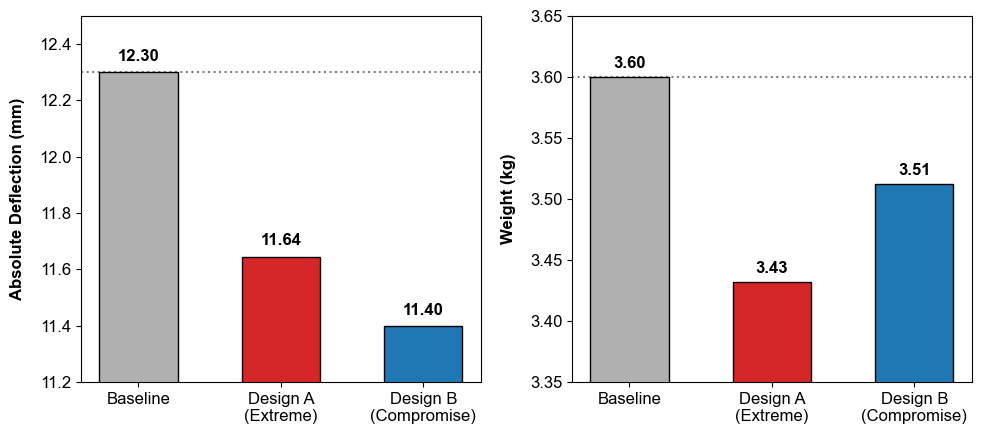

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 논문용 폰트 및 스타일 설정
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = 12

labels = ['Baseline', 'Design A\n(Extreme)', 'Design B\n(Compromise)']
deflection = [12.300, 11.645, 11.397]
weight = [3.600, 3.432, 3.512]

# 색상 설정: Baseline(회색), Design A(빨간색 톤), Design B(파란색 톤)
colors = ['#B0B0B0', '#d62728', '#1f77b4']

# 논문용으로 깔끔하게 상단 여백을 줄이고 차트 영역에 집중
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

# --- Plot 1: Deflection ---
bars1 = ax1.bar(labels, deflection, color=colors, edgecolor='black', width=0.55, zorder=3)
ax1.set_ylabel('Absolute Deflection (mm)', fontweight='bold', labelpad=10)
# 성능 차이가 잘 보이도록 Y축 범위 조정
ax1.set_ylim(11.2, 12.5) 
# 그리드 제거 (해당 줄 삭제 또는 주석 처리)
# ax1.grid(axis='y', linestyle='--', alpha=0.7, zorder=0) 

# 기준선 표시 (Baseline)
ax1.axhline(y=12.3, color='gray', linestyle=':', linewidth=1.5, zorder=1)

# 값 라벨 표시
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.03, f'{yval:.2f}', 
             ha='center', va='bottom', fontweight='bold')

# --- Plot 2: Weight ---
bars2 = ax2.bar(labels, weight, color=colors, edgecolor='black', width=0.55, zorder=3)
ax2.set_ylabel('Weight (kg)', fontweight='bold', labelpad=10)
# 성능 차이가 잘 보이도록 Y축 범위 조정
ax2.set_ylim(3.35, 3.65)
# 그리드 제거 (해당 줄 삭제 또는 주석 처리)
# ax2.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

# 기준선 표시 (Baseline)
ax2.axhline(y=3.6, color='gray', linestyle=':', linewidth=1.5, zorder=1)

# 값 라벨 표시
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.2f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
# bbox_inches='tight'가 여백을 깔끔하게 잘라줍니다.
plt.savefig('PV_Performance_Comparison_BarChart_NoGrid.png', dpi=300, bbox_inches='tight')
plt.show()